In [ ]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, PredefinedSplit

from sklearn.metrics import accuracy_score, classification_report, f1_score
import time

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models_eval import eval_pipeline, eval_combination_matrix

from rital_nlp_project.presidents.utils import smooth_predictions, concat_seq_by_class

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
texts_pres, classes_pres = load_clean_data("../Dataset/presidents_clean.parquet")

In [93]:
max_features = 5000
min_df = 5
max_df = 0.5

vectorizer_list = [
    CountVectorizer(analyzer="char", ngram_range=(1, 1), max_features=max_features),
    CountVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),

    TfidfVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
]

classifier_list = [
    LogisticRegression(max_iter=100),
    MultinomialNB(), 
    LinearSVC(),
    #SVC(kernel="rbf")
]

### Separated phrases

In [55]:
# Train/test split
# X_train, X_test, y_train, y_test = train_test_split(texts_pres, classes_pres, random_state=42)

split_idx = int(len(texts_pres) * 0.8)

X_train = texts_pres[:split_idx]
X_test  = texts_pres[split_idx:]
y_train = classes_pres[:split_idx]
y_test  = classes_pres[split_idx:]

In [41]:
np.unique(y_test, return_counts=True)

(array([-1,  1]), array([ 1163, 10320]))

In [3]:
#results = eval_combination_matrix(X_train, y_train, X_test, y_test, vectorizer_list, classifier_list)
#results.to_csv("out/baseline_eval_matrix_pres.csv", index=False)
results = pd.read_csv("out/baseline_eval_matrix_pres.csv")

Text(0.5, 1.0, 'F1-score')

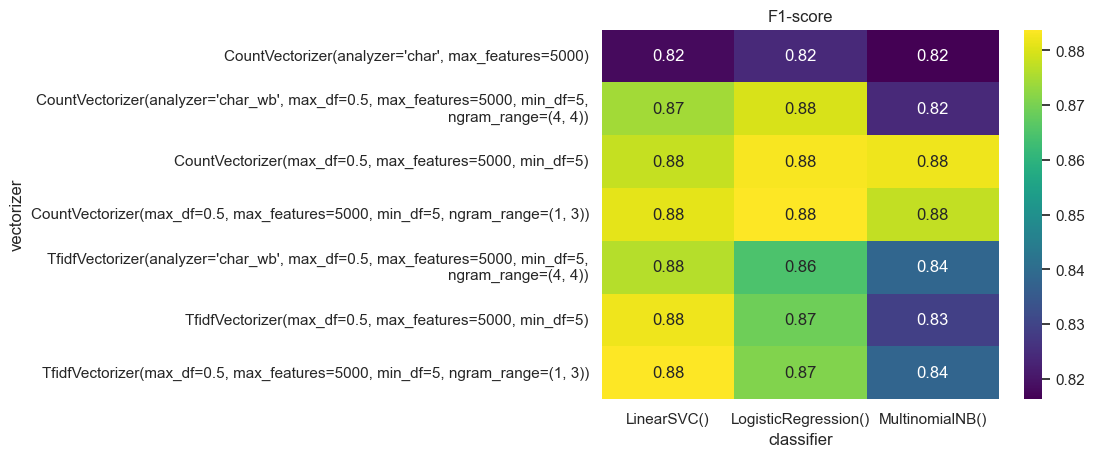

In [7]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="f1"), annot=True, cmap="viridis")
plt.title("F1-score")

Text(0.5, 1.0, 'Train time')

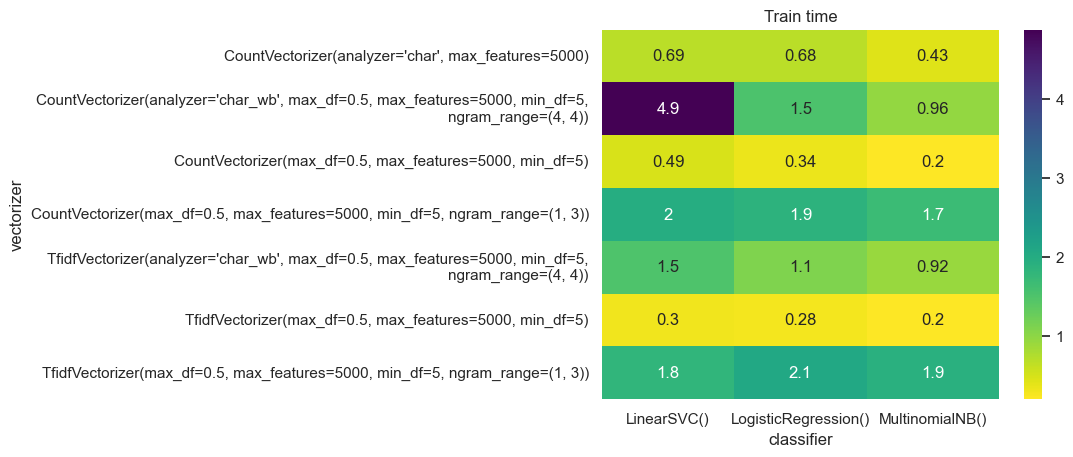

In [6]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="train_time"), annot=True, cmap="viridis_r")
plt.title("Train time")

### Try smoothing

In [ ]:
speaker_ids = np.array(classes_pres)

unique_speakers = np.unique(speaker_ids)
n_splits = 5
fold_ids = np.zeros(len(speaker_ids), dtype=int)

for s in unique_speakers:
    idx = np.where(speaker_ids == s)[0]
    blocks = np.array_split(idx, n_splits)
    for k, b in enumerate(blocks):
        fold_ids[b] = k

ps = PredefinedSplit(test_fold=fold_ids)
train_idx, test_idx = next(ps.split())
X_train = [texts_pres[i] for i in train_idx]
X_test = [texts_pres[i] for i in test_idx]
y_train, y_test = classes_pres[train_idx], classes_pres[test_idx]

X_train_concat, y_train_concat = concat_seq_by_class(X_train, y_train)

In [109]:
labels, counts = np.unique(y_train, return_counts=True)
labels, counts

(array([-1,  1]), array([ 6018, 39912]))

In [ ]:
pipeline = Pipeline([
    ("vectorizer", CountVectorizer(analyzer="word", ngram_range=(1, 1), min_df=min_df, max_df=max_df, max_features=max_features)),
    ("classifier", MultinomialNB())
])

eval_pipeline(texts_pres, classes_pres, X_train_concat, y_train_concat, X_test, y_test, pipeline, True)

Pipeline steps:
  vectorizer: CountVectorizer(max_df=0.5, max_features=5000, min_df=5)
  classifier: MultinomialNB()
Cross-validation F1 scores: [0.93561259 0.93116644 0.9293861  0.93239701 0.92926574], mean: 0.9316
Cross-validation Accuracy scores: [0.88617957 0.87938692 0.87599059 0.88094409 0.87641526], mean:  0.8798
Cross-validation AUC scores: [0.84479053 0.84274257 0.83902546 0.84889316 0.83755849], mean: 0.8426
Training time: 0.177 seconds
Inference time: 0.051 seconds
Vocabulary size: 5000
Test Accuracy: 0.8780
Test F1-score: 0.9303
Test ROC-AUC: 0.7103
              precision    recall  f1-score   support

          -1       0.54      0.48      0.51      1505
           1       0.92      0.94      0.93      9978

    accuracy                           0.88     11483
   macro avg       0.73      0.71      0.72     11483
weighted avg       0.87      0.88      0.88     11483




In [100]:
pipeline.fit(X_train, y_train)
preds_raw = pipeline.predict(X_test)
preds_probas = pipeline.predict_proba(X_test)
preds_probas_smooth = smooth_predictions(preds_probas, sigma=1)
preds_smooth = pipeline.classes_[np.argmax(preds_probas_smooth, axis=1)]

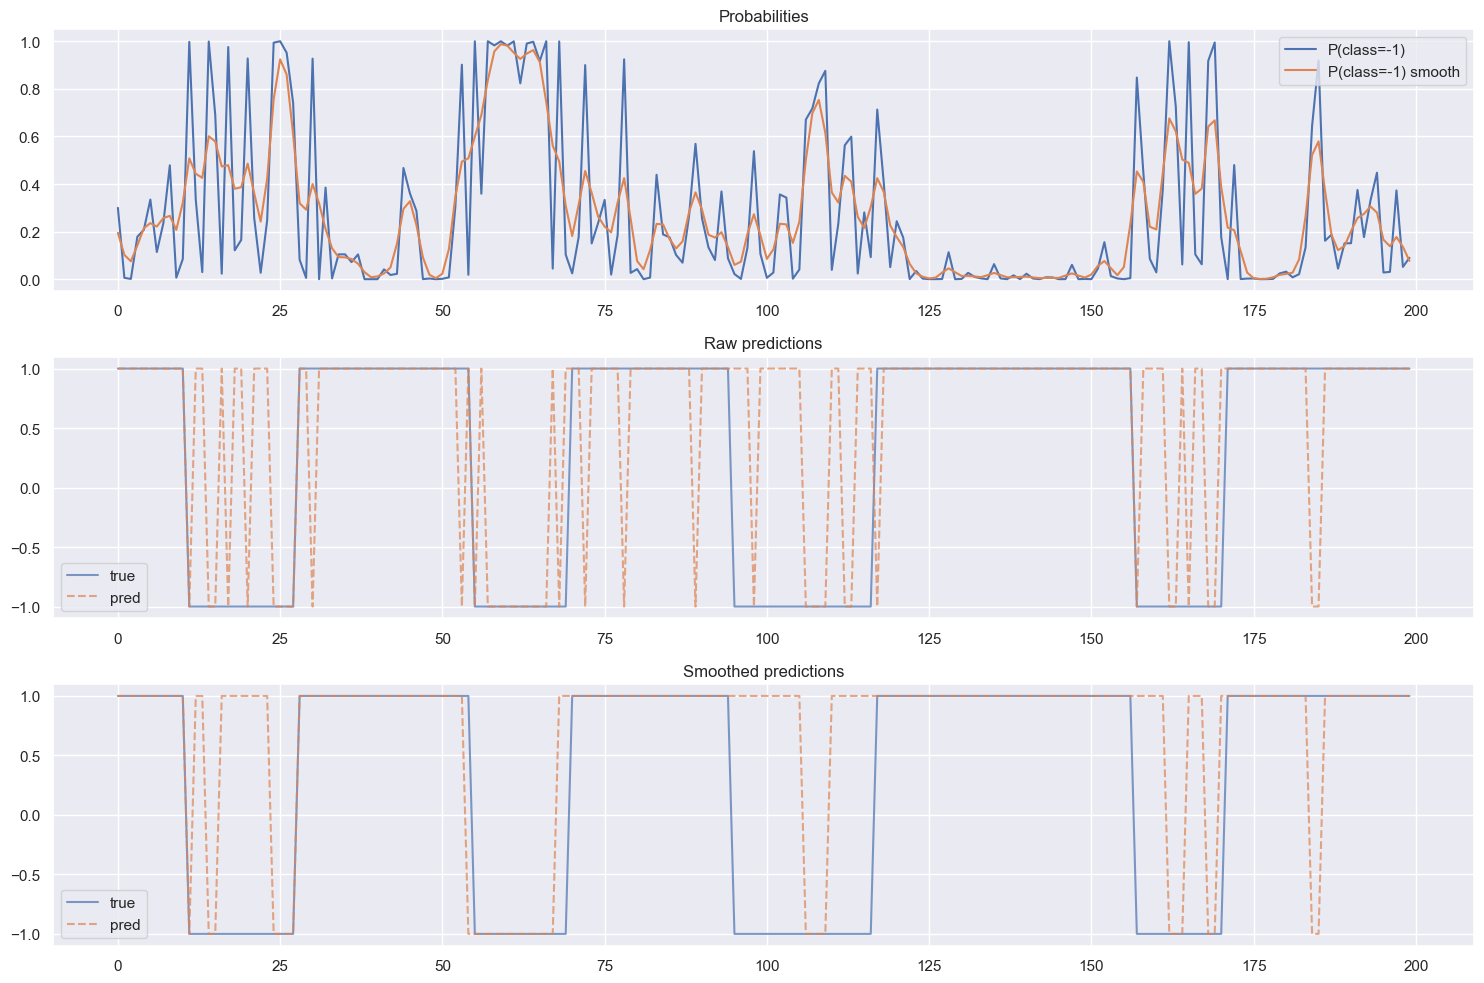

In [101]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))
limit = 200

ax1.set_title("Probabilities")
sns.lineplot(preds_probas[:limit, 0], label=f"P(class={pipeline.classes_[0]})", ax=ax1)
sns.lineplot(preds_probas_smooth[:limit, 0], label=f"P(class={pipeline.classes_[0]}) smooth", ax=ax1)

ax2.set_title("Raw predictions")
sns.lineplot(y_test[:limit], label="true", ax=ax2, alpha=0.7)
sns.lineplot(preds_raw[:limit], label="pred", ax=ax2, alpha=0.7, linestyle="--")

ax3.set_title("Smoothed predictions")
sns.lineplot(y_test[:limit], label="true", ax=ax3, alpha=0.7)
sns.lineplot(preds_smooth[:limit], label="pred", ax=ax3, alpha=0.7, linestyle="--")

plt.tight_layout()

In [102]:
print(f1_score(y_test, preds_raw))
print(f1_score(y_test, preds_smooth))

print(classification_report(y_test, preds_raw))
print(classification_report(y_test, preds_smooth))

0.9303366316940977
0.95792691803756
              precision    recall  f1-score   support

          -1       0.54      0.48      0.51      1505
           1       0.92      0.94      0.93      9978

    accuracy                           0.88     11483
   macro avg       0.73      0.71      0.72     11483
weighted avg       0.87      0.88      0.88     11483

              precision    recall  f1-score   support

          -1       0.87      0.50      0.63      1505
           1       0.93      0.99      0.96      9978

    accuracy                           0.92     11483
   macro avg       0.90      0.74      0.80     11483
weighted avg       0.92      0.92      0.92     11483

